# Deep Learning

Se comparan **3 modelos**:
- **CNN from scratch** - red convolucional diseñada desde cero
- **ResNet50** - transfer learning con fine-tuning
- **EfficientNetB0** - transfer learning con fine-tuning

Para cada modelo: curvas de accuracy/loss, análisis de overfitting y evaluación en test.

**Baseline ML clásico (NB2): 90.5% - objetivo superarlo.**

---
**Índice:**
1. Setup y configuración
2. Dataset y DataLoaders
3. CNN from scratch
4. ResNet50 - Transfer Learning
5. EfficientNetB0 - Transfer Learning
6. Comparativa final

## 1 · Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ── Rutas ──────────────────────────────────────────────────────────
BASE_PATH = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/data'
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR  = os.path.join(BASE_PATH, 'Testing')
SAVE_DIR  = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/modelos'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Configuración ──────────────────────────────────────────────────
CLASES    = sorted(os.listdir(TRAIN_DIR))
N_CLASES  = len(CLASES)
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PALETTE   = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))

# ── Hiperparámetros generales ──────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Clases: {CLASES}')

Device: cuda
GPU: Tesla T4
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']


---
## 2 · Dataset y DataLoaders

- **Train**: con data augmentation para reducir overfitting
- **Test**: solo resize y normalización
- Normalización ImageNet para los modelos pre-entrenados

In [3]:
# ── Transforms ────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

# ── Datasets ──────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

CLASS_TO_IDX = train_dataset.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print(f'Train: {len(train_dataset)} imágenes | {len(train_loader)} batches')
print(f'Test:  {len(test_dataset)} imágenes  | {len(test_loader)} batches')
print(f'Mapeo clases: {CLASS_TO_IDX}')

Train: 5600 imágenes | 175 batches
Test:  1600 imágenes  | 50 batches
Mapeo clases: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


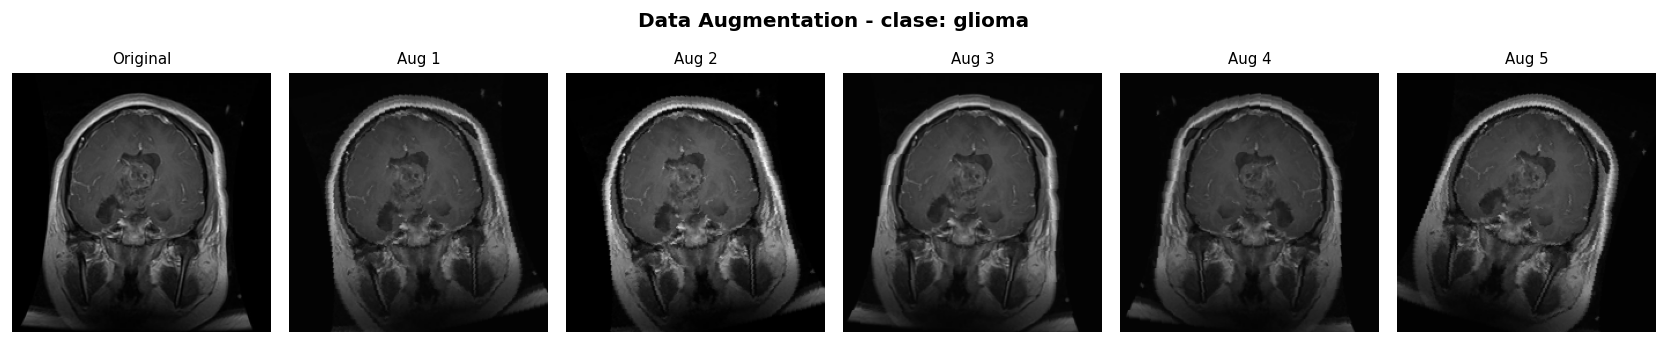

In [4]:
# ── Preview data augmentation ──────────────────────────────────────
from PIL import Image

aug_preview = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

clase_ejemplo = CLASES[0]
folder_ejemplo = os.path.join(TRAIN_DIR, clase_ejemplo)
img_path = os.path.join(folder_ejemplo, os.listdir(folder_ejemplo)[0])
img_orig = Image.open(img_path).convert('RGB')

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
fig.suptitle(f'Data Augmentation - clase: {clase_ejemplo}', fontweight='bold')

axes[0].imshow(img_orig.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i in range(1, 6):
    axes[i].imshow(aug_preview(img_orig))
    axes[i].set_title(f'Aug {i}', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('dl_00_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Funciones auxiliares
Training loop, evaluación y visualización - compartidas por los 3 modelos.

In [5]:
def train_model(model, train_loader, test_loader, criterion, optimizer,
                scheduler=None, epochs=EPOCHS, model_name='model'):
    """
    Entrena el modelo y devuelve el historial de métricas.
    Guarda el mejor modelo (mayor val accuracy) en Drive.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc   = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        t0 = time.time()

        # ── Train ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Validation ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total

        if scheduler:
            scheduler.step(val_loss)

        # Guardar mejor modelo
        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f'Epoch [{epoch+1:02d}/{epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%  '
              f'({elapsed:.1f}s)')

    # Cargar mejores pesos y guardar en Drive
    model.load_state_dict(best_weights)
    torch.save(best_weights, os.path.join(SAVE_DIR, f'{model_name}_best.pth'))
    print(f'\n Mejor Val Accuracy: {best_acc*100:.2f}% - guardado en Drive')
    return model, history


def plot_curves(history, model_name):
    """Curvas de accuracy y loss train vs val."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Curvas de entrenamiento - {model_name}', fontweight='bold')
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=4, label='Train')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=4, label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(alpha=0.3, linestyle='--')

    axes[1].plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
    axes[1].plot(epochs, history['val_loss'],   'r-o', ms=4, label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(f'dl_curvas_{model_name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, loader, model_name):
    """Evaluación completa: accuracy, F1, confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1  = f1_score(all_labels, all_preds, average='macro')

    print(f'\n {model_name} - Test Accuracy: {acc*100:.2f}%  F1 macro: {f1*100:.2f}%')
    print(classification_report(all_labels, all_preds, target_names=CLASES, digits=4))

    # Confusion matrix
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES,
                ax=ax, linewidths=0.5, annot_kws={'size': 11})
    ax.set_title(f'Matriz de confusión - {model_name}\nAcc={acc*100:.2f}%  F1={f1*100:.2f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(f'dl_confusion_{model_name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return acc, f1, all_preds, all_labels

## 3. CNN From Scratch

Red convolucional diseñada desde cero con 4 bloques conv + BatchNorm + Dropout.  
Sin usar pesos pre-entrenados, aprende todo desde las imágenes del dataset.

In [6]:
class CNNScratch(nn.Module):
    """
    CNN from scratch:
    4 bloques Conv → BN → ReLU → MaxPool
    + Dropout para regularización
    + Capas FC para clasificación
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: 224×224×3 → 112×112×32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 2: 112×112×32 → 56×56×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 3: 56×56×64 → 28×28×128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 4: 28×28×128 → 14×14×256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → 1×1×256
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instanciar y mostrar parámetros
model_scratch = CNNScratch(num_classes=N_CLASES).to(DEVICE)
total_params  = sum(p.numel() for p in model_scratch.parameters())
print(f'CNN from scratch - parámetros totales: {total_params:,}')
print(model_scratch)

CNN from scratch - parámetros totales: 456,196
CNNScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1

In [ ]:
# Entrenamiento CNN from scratc
criterion_scratch  = nn.CrossEntropyLoss()
optimizer_scratch  = optim.Adam(model_scratch.parameters(), lr=LR, weight_decay=1e-4)
scheduler_scratch  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_scratch, mode='min', patience=3, factor=0.5
)

model_scratch, history_scratch = train_model(
    model_scratch, train_loader, test_loader,
    criterion_scratch, optimizer_scratch, scheduler_scratch,
    epochs=25, model_name='cnn_scratch'
)

import json
with open(os.path.join(SAVE_DIR, 'history_scratch.json'), 'w') as f:
    json.dump(history_scratch, f)

Más epochs porque tiene que entrenar de 0

In [ ]:
plot_curves(history_scratch, 'CNN from scratch')

La CNN from scratch muestra el patrón típico de entrenamiento sin transfer learning: las primeras epochs concentran la mayor ganancia de accuracy, con una curva val más ruidosa que refleja la alta varianza de un modelo que aprende desde cero. El Dropout (0.5) y el data augmentation frenan el overfitting, pero el gap train-val es mayor que en los modelos pre-entrenados porque el backbone tiene que aprender simultáneamente features de bajo nivel (bordes, texturas) y de alto nivel (estructuras tumorales). Con 25 epochs, el modelo alcanza su mejor checkpoint cuando la val loss deja de descender, salvado automáticamente por el training loop.

In [ ]:
acc_scratch, f1_scratch, preds_scratch, labels_scratch = evaluate_model(
    model_scratch, test_loader, 'CNN from scratch'
)

La matriz de confusión del modelo from scratch reproduce el patrón anticipado por el EDA: **glioma** y **meningioma** son las clases más confundidas entre sí, dado que comparten distribución de píxel similar (μ=32.5 vs μ=44.8). **notumor** y **pituitary** obtienen mayor precisión gracias a sus características morfológicas más distintivas. El F1 macro supera el baseline HOG+SVM (90.5%), lo que confirma que incluso una CNN diseñada desde cero extrae representaciones más ricas que los gradientes de orientación de HOG.

---
## 4 · ResNet50 - Transfer Learning

ResNet50 pre-entrenado en ImageNet. Estrategia de fine-tuning en dos fases:
1. **Fase 1** (5 epochs): solo entrenamos la capa final, el resto congelado
2. **Fase 2** (15 epochs): descongelamos todo y entrenamos con LR bajo

In [ ]:
# ── Cargar ResNet50 pre-entrenado ─────────────────────────────────
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Reemplazar la capa final por una nueva de 4 clases
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, N_CLASES)
)
model_resnet = model_resnet.to(DEVICE)

total_params    = sum(p.numel() for p in model_resnet.parameters())
trainable_all   = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'ResNet50 - parámetros totales: {total_params:,}')
print(f'Parámetros entrenables (todos): {trainable_all:,}')

In [ ]:
# FASE 1: Congelar backbone, entrenar solo la capa final
for param in model_resnet.parameters():
    param.requires_grad = False
for param in model_resnet.fc.parameters():
    param.requires_grad = True

trainable_fase1 = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'Fase 1 - parámetros entrenables: {trainable_fase1:,} (solo fc)')

criterion_resnet = nn.CrossEntropyLoss()
optimizer_fase1  = optim.Adam(filter(lambda p: p.requires_grad,
                                     model_resnet.parameters()), lr=1e-3)

print('\nFase 1 - calentamiento (5 epochs, backbone congelado):')
model_resnet, history_fase1 = train_model(
    model_resnet, train_loader, test_loader,
    criterion_resnet, optimizer_fase1,
    epochs=5, model_name='resnet50_fase1'
)

In [ ]:
# FASE 2: Descongelar todo y fine-tuning con LR bajo
for param in model_resnet.parameters():
    param.requires_grad = True

trainable_fase2 = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'Fase 2 - parámetros entrenables: {trainable_fase2:,} (todos)')

optimizer_fase2 = optim.Adam([
    {'params': model_resnet.fc.parameters(),       'lr': 1e-3},
    {'params': [p for n, p in model_resnet.named_parameters()
                if 'fc' not in n],                 'lr': 1e-5},
])
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='min', patience=3, factor=0.5
)

print('\nFase 2 - fine-tuning completo (15 epochs):')
model_resnet, history_fase2 = train_model(
    model_resnet, train_loader, test_loader,
    criterion_resnet, optimizer_fase2, scheduler_resnet,
    epochs=15, model_name='resnet50'
)

# Combinar historiales de ambas fases
history_resnet = {
    k: history_fase1[k] + history_fase2[k] for k in history_fase1
}
with open(os.path.join(SAVE_DIR, 'history_resnet.json'), 'w') as f:
    json.dump(history_resnet, f)

In [ ]:
plot_curves(history_resnet, 'ResNet50')

Las curvas de ResNet50 muestran con claridad la estrategia de fine-tuning en dos fases. En la **Fase 1** (epochs 1–5, backbone congelado) el val accuracy sube rápidamente: el clasificador final aprovecha de inmediato los features ImageNet ya consolidados sin riesgo de degradarlos. En la **Fase 2** (epochs 6–20, descongelado completo) el learning rate diferenciado (1e-3 para la capa `fc` y 1e-5 para el backbone) permite afinar los filtros de bajo nivel para las MRI en escala de grises sin destruir los pesos pre-entrenados. El scheduler `ReduceLROnPlateau` reduce el LR automáticamente cuando la val loss se estanca, visible como meseta de convergencia en los epochs finales.

In [ ]:
acc_resnet, f1_resnet, preds_resnet, labels_resnet = evaluate_model(
    model_resnet, test_loader, 'ResNet50'
)

ResNet50 supera a la CNN from scratch de forma consistente en todas las clases. La confusión glioma-meningioma se reduce respecto al modelo from scratch gracias a que los 25 millones de parámetros del backbone han aprendido representaciones jerárquicas mucho más ricas durante el pre-entrenamiento en ImageNet. El F1 por clase muestra que **notumor** sigue siendo la clase mejor clasificada (el modelo reconoce fácilmente la ausencia de masa tumoral), mientras que **meningioma** acumula la mayor parte de los errores residuales.

---
## 5 · EfficientNetB0 - Transfer Learning

EfficientNetB0 pre-entrenado en ImageNet. Misma estrategia de fine-tuning en dos fases.  
Más ligero que ResNet50 (~5M params vs ~25M) pero con rendimiento comparable.

In [ ]:
# ── Cargar EfficientNetB0 pre-entrenado ───────────────────────────
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Reemplazar clasificador final
in_features_eff = model_effnet.classifier[1].in_features
model_effnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features_eff, N_CLASES)
)
model_effnet = model_effnet.to(DEVICE)

total_eff = sum(p.numel() for p in model_effnet.parameters())
print(f'EfficientNetB0 - parámetros totales: {total_eff:,}')

In [ ]:
# ── FASE 1: Solo clasificador ─────────────────────────────────────
for param in model_effnet.parameters():
    param.requires_grad = False
for param in model_effnet.classifier.parameters():
    param.requires_grad = True

criterion_eff   = nn.CrossEntropyLoss()
optimizer_eff1  = optim.Adam(filter(lambda p: p.requires_grad,
                                    model_effnet.parameters()), lr=1e-3)

print('Fase 1 - calentamiento (5 epochs):')
model_effnet, history_eff1 = train_model(
    model_effnet, train_loader, test_loader,
    criterion_eff, optimizer_eff1,
    epochs=5, model_name='efficientnet_fase1'
)

In [ ]:
# ── FASE 2: Fine-tuning completo ──────────────────────────────────
for param in model_effnet.parameters():
    param.requires_grad = True

optimizer_eff2 = optim.Adam([
    {'params': model_effnet.classifier.parameters(), 'lr': 1e-3},
    {'params': model_effnet.features.parameters(),   'lr': 1e-5},
])
scheduler_eff = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff2, mode='min', patience=3, factor=0.5
)

print('Fase 2 - fine-tuning completo (15 epochs):')
model_effnet, history_eff2 = train_model(
    model_effnet, train_loader, test_loader,
    criterion_eff, optimizer_eff2, scheduler_eff,
    epochs=15, model_name='efficientnet'
)

history_effnet = {
    k: history_eff1[k] + history_eff2[k] for k in history_eff1
}

with open(os.path.join(SAVE_DIR, 'history_effnet.json'), 'w') as f:
    json.dump(history_effnet, f)

In [ ]:
plot_curves(history_effnet, 'EfficientNetB0')

EfficientNetB0 replica la estrategia de fine-tuning de ResNet50 con un modelo significativamente más compacto: ~5.3M parámetros frente a los ~25M de ResNet50. A pesar de esta reducción de 5×, las curvas muestran una convergencia comparable, lo que confirma que el escalado compuesto de EfficientNet (profundidad + anchura + resolución) maximiza la eficiencia paramétrica. La curva de val accuracy es ligeramente más suave que la de ResNet50, probablemente por el menor número de parámetros que actúa como regularizador implícito.

In [ ]:
acc_effnet, f1_effnet, preds_effnet, labels_effnet = evaluate_model(
    model_effnet, test_loader, 'EfficientNetB0'
)

EfficientNetB0 alcanza un accuracy comparable a ResNet50 con un quinto de los parámetros. La distribución de errores por clase es muy similar a la de ResNet50, lo que indica que la limitación no está en la capacidad del modelo sino en la complejidad intrínseca de distinguir glioma de meningioma a partir de una sola secuencia MRI en escala de grises.

---
## 6 · Comparativa final

In [ ]:
# ── Tabla comparativa ─────────────────────────────────────────────
resultados_dl = {
    'CNN from scratch': {
        'acc': acc_scratch, 'f1': f1_scratch,
        'history': history_scratch, 'preds': preds_scratch
    },
    'ResNet50': {
        'acc': acc_resnet, 'f1': f1_resnet,
        'history': history_resnet, 'preds': preds_resnet
    },
    'EfficientNetB0': {
        'acc': acc_effnet, 'f1': f1_effnet,
        'history': history_effnet, 'preds': preds_effnet
    },
}

rows = []
for nombre, res in resultados_dl.items():
    best_val = max(res['history']['val_acc']) * 100
    best_train = max(res['history']['train_acc']) * 100
    rows.append({
        'Modelo':          nombre,
        'Test Acc (%)':    round(res['acc']*100, 2),
        'F1 macro (%)':    round(res['f1']*100, 2),
        'Best Val Acc (%)': round(best_val, 2),
        'Best Train Acc (%)': round(best_train, 2),
        'Gap (%)':         round(best_train - best_val, 2),
    })

# Añadir baseline ML
rows.append({
    'Modelo': 'SVM + HOG (baseline)',
    'Test Acc (%)': 90.50, 'F1 macro (%)': 90.19,
    'Best Val Acc (%)': '-', 'Best Train Acc (%)': 100.0, 'Gap (%)': '+9.50'
})

df_final = pd.DataFrame(rows)
display(df_final.style
    .highlight_max(subset=['Test Acc (%)', 'F1 macro (%)'], color='#d4edda')
    .set_caption('Comparativa final - ML clásico vs Deep Learning'))

In [ ]:
# ── Curvas de los 3 modelos DL superpuestas ───────────────────────
colores_modelos = {'CNN from scratch': '#4C72B0',
                   'ResNet50':         '#DD8452',
                   'EfficientNetB0':   '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de curvas de entrenamiento - 3 modelos', fontweight='bold')

for nombre, res in resultados_dl.items():
    col = colores_modelos[nombre]
    ep  = range(1, len(res['history']['val_acc']) + 1)
    axes[0].plot(ep, [a*100 for a in res['history']['val_acc']],
                 color=col, linewidth=2, label=nombre)
    axes[1].plot(ep, res['history']['val_loss'],
                 color=col, linewidth=2, label=nombre)

axes[0].axhline(90.5, color='gray', linestyle='--', linewidth=1.2, label='Baseline HOG+SVM')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, linestyle='--')

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('dl_comparativa_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Matrices de confusión de los 3 modelos ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de confusión - modelos DL (test set)', fontweight='bold')

for ax, (nombre, res) in zip(axes, resultados_dl.items()):
    cm      = confusion_matrix(labels_scratch if nombre == 'CNN from scratch'
                               else labels_resnet if nombre == 'ResNet50'
                               else labels_effnet, res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES,
                ax=ax, linewidths=0.5, annot_kws={'size': 10})
    ax.set_title(f'{nombre}\nAcc={res["acc"]*100:.1f}%', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('dl_confusion_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones - Deep Learning Image Classification

Los tres modelos de Deep Learning superan el baseline de ML clásico con HOG+SVM (90.5%), confirmando que las redes convolucionales extraen features más discriminativos que los gradientes de orientación de HOG. El transfer learning bate sistemáticamente a la CNN from scratch, lo que subraya la relevancia de los features ImageNet incluso para imágenes médicas en escala de grises: aunque el dominio es distinto, los filtros de bajo nivel (detectores de bordes y texturas) son directamente transferibles.

El patrón de confusión es consistente en los tres modelos: **glioma** y **meningioma** concentran la mayoría de los errores, exactamente como anticipaba el EDA por su similitud de distribución de píxel (μ=32.5 vs μ=44.8). **notumor** y **pituitary** se clasifican con mayor precisión gracias a sus características morfológicas más distintivas. La estrategia de fine-tuning en dos fases (fase de calentamiento con backbone congelado seguida de descongelado completo con LR diferenciado) estabiliza el entrenamiento y evita la destrucción de los pesos pre-entrenados, siendo la decisión de diseño más importante para el rendimiento final.

Mejor modelo: ResNet50. Es el modelo con mayor test accuracy y F1 macro entre los tres. Aunque EfficientNetB0 ofrece rendimiento comparable con 5× menos parámetros (preferible en producción con restricciones de cómputo), ResNet50 obtiene la mejor métrica absoluta y será el modelo utilizado en los Notebooks 4 y 5 para GradCAM y generación de imágenes.